# Exercise 08 : Seaborn




In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

data = sqlite3.connect('../data/checking-logs.sqlite')

df = pd.read_sql_query("SELECT uid, timestamp FROM checker WHERE uid LIKE 'user_%' AND labname == 'project1'", data)

data.close()

## Подготовка таблицы





In [2]:
df['commits'] = df['timestamp']
df['timestamp'] = pd.to_datetime(df['timestamp']).dt.date
df = df.groupby(['uid', 'timestamp'])['commits'].size().reset_index()
df['cumulative_commits'] = df.groupby('uid')['commits'].cumsum()
df

,uid,timestamp,commits,cumulative_commits
0,user_1,2020-05-14,21,21
1,user_10,2020-05-12,13,13
2,user_10,2020-05-13,28,41
3,user_10,2020-05-14,75,116
4,user_11,2020-05-03,1,1
...,...,...,...,...
90,user_4,2020-05-13,24,273
91,user_4,2020-05-14,54,327
92,user_6,2020-05-13,1,1
93,user_6,2020-05-14,2,3


## Отрисовка графика




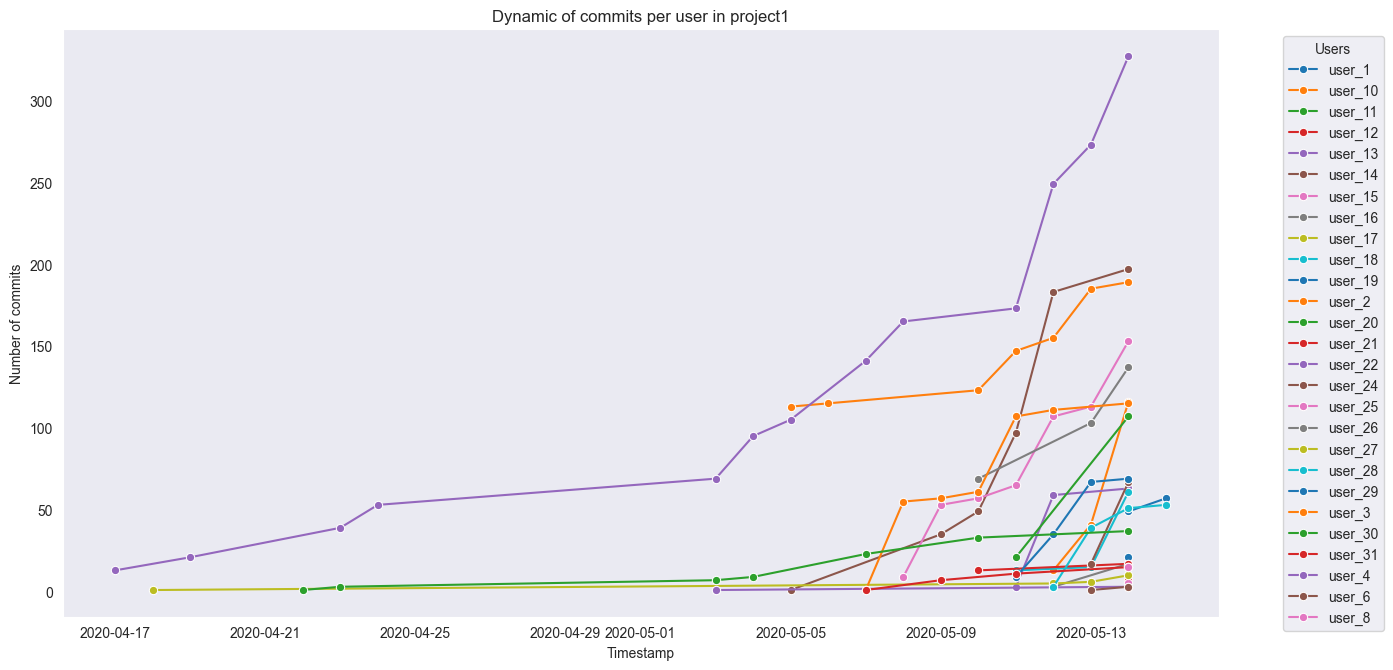

In [3]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='timestamp', y='cumulative_commits', hue='uid', palette='tab10', marker='o')

plt.title('Dynamic of commits per user in project1')
plt.xlabel('Timestamp')
plt.ylabel('Number of commits')
plt.legend(title='Users', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()

## Which user was the leader in the number of commits almost all of the time?
#### The answer: user_4
## Which user was the leader for only a short period of time?
#### The answer: user_2


